In this project we will complete the following steps and answer the followng questions:
1) Load your datasets and perform some simple exploratory data analysis.
2) Create a new column to represent the like-dislike ratio (likes divided by dislikes) for the videos in each dataset.
3) What is the average like-dislike ratio for all of the videos? (average number of likes per video divided by the average number of dislikes per video).
4) Perform data manipulation to find the average number of likes per video for the US and GB in the year 2018.
5) **Business report:** Your client hypothesizes that the most polarizing videos get shared the most. Analyze the data to determine whether your client is correct, and what other metrics should be investigated. Be sure to define any terms or cutoffs you make in the data. Present your findings in a short report for the client to review.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# loading the first dataframe and examining
df_US = pd.read_csv('USvideos.csv')
print(df_US.columns)
print(df_US.info())
print(df_US.head())

Index(['video_id', 'trending_date', 'title', 'channel_title', 'category_id',
       'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count',
       'thumbnail_link', 'comments_disabled', 'ratings_disabled',
       'video_error_or_removed', 'description'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40949 entries, 0 to 40948
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   video_id                40949 non-null  object
 1   trending_date           40949 non-null  object
 2   title                   40949 non-null  object
 3   channel_title           40949 non-null  object
 4   category_id             40949 non-null  int64 
 5   publish_time            40949 non-null  object
 6   tags                    40949 non-null  object
 7   views                   40949 non-null  int64 
 8   likes                   40949 non-null  int64 
 9   dislikes              

In [2]:
df_GB = pd.read_csv('GBvideos.csv')
print(df_GB.head())

      video_id trending_date  \
0  Jw1Y-zhQURU      17.14.11   
1  3s1rvMFUweQ      17.14.11   
2  n1WpP7iowLc      17.14.11   
3  PUTEiSjKwJU      17.14.11   
4  rHwDegptbI4      17.14.11   

                                               title  \
0      John Lewis Christmas Ad 2017 - #MozTheMonster   
1          Taylor Swift: …Ready for It? (Live) - SNL   
2         Eminem - Walk On Water (Audio) ft. Beyoncé   
3  Goals from Salford City vs Class of 92 and Fri...   
4  Dashcam captures truck's near miss with child ...   

                channel_title  category_id              publish_time  \
0                  John Lewis           26  2017-11-10T07:38:29.000Z   
1         Saturday Night Live           24  2017-11-12T06:24:44.000Z   
2                  EminemVEVO           10  2017-11-10T17:00:03.000Z   
3  Salford City Football Club           17  2017-11-13T02:30:38.000Z   
4            Cute Girl Videos           25  2017-11-13T01:45:13.000Z   

                                     

In [3]:
# two columns should be datetime but are listed as objects: trending_date, publish_time
# converting columsn to datetime
df_US.publish_time = pd.to_datetime(df_US.publish_time)
df_GB.publish_time = pd.to_datetime(df_GB.publish_time)

df_US.trending_date = pd.to_datetime(df_US.trending_date, format='%y.%d.%m') # date format is unique
df_GB.trending_date = pd.to_datetime(df_GB.trending_date, format='%y.%d.%m')

print(df_US.publish_time.head())
print(df_GB.publish_time.head())

print(df_US.info())
print(df_GB.info())

0   2017-11-13 17:13:01+00:00
1   2017-11-13 07:30:00+00:00
2   2017-11-12 19:05:24+00:00
3   2017-11-13 11:00:04+00:00
4   2017-11-12 18:01:41+00:00
Name: publish_time, dtype: datetime64[ns, UTC]
0   2017-11-10 07:38:29+00:00
1   2017-11-12 06:24:44+00:00
2   2017-11-10 17:00:03+00:00
3   2017-11-13 02:30:38+00:00
4   2017-11-13 01:45:13+00:00
Name: publish_time, dtype: datetime64[ns, UTC]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40949 entries, 0 to 40948
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   video_id                40949 non-null  object             
 1   trending_date           40949 non-null  datetime64[ns]     
 2   title                   40949 non-null  object             
 3   channel_title           40949 non-null  object             
 4   category_id             40949 non-null  int64              
 5   publish_time            40949 non-nul

In [4]:
print(df_US.trending_date.drop_duplicates().head(30)) # need a few more rows to validate date format and drop_duplicates helps display more unique dates
print(df_GB.trending_date.drop_duplicates().head(30))

0      2017-11-14
200    2017-11-15
400    2017-11-16
600    2017-11-17
800    2017-11-18
1000   2017-11-19
1200   2017-11-20
1400   2017-11-21
1600   2017-11-22
1800   2017-11-23
2000   2017-11-24
2200   2017-11-25
2400   2017-11-26
2600   2017-11-27
2800   2017-11-28
3000   2017-11-29
3200   2017-11-30
3400   2017-12-01
3600   2017-12-02
3800   2017-12-03
4000   2017-12-04
4200   2017-12-05
4400   2017-12-06
4600   2017-12-07
4800   2017-12-08
5000   2017-12-09
5200   2017-12-10
5400   2017-12-11
5600   2017-12-12
5800   2017-12-13
Name: trending_date, dtype: datetime64[ns]
0      2017-11-14
200    2017-11-15
399    2017-11-16
598    2017-11-17
798    2017-11-18
998    2017-11-19
1198   2017-11-20
1398   2017-11-21
1598   2017-11-22
1798   2017-11-23
1998   2017-11-24
2198   2017-11-25
2398   2017-11-26
2598   2017-11-27
2798   2017-11-28
2998   2017-11-29
3198   2017-11-30
3398   2017-12-01
3596   2017-12-02
3795   2017-12-03
3994   2017-12-04
4194   2017-12-05
4394   2017-12-06
459

In [5]:
# datatypes are corrrected and datetime format looks consistent
# quantifying the missing values in description column
print(df_US.description.isnull().sum())
print(df_GB.description.isnull().sum())

570
612


Out of 40949 entries, 570 descriptions are left missing in the US data set. Out of 38916, 612 are missing from the Great Britian dataset. I'll keep the missing entries in to check for confounding variables, but we are examining views and like to dislike ratios so it's likely not important.

In [6]:
print(df_US.duplicated().sum())
print(df_US.video_id.nunique())
print(df_GB.duplicated().sum())
print(df_GB.video_id.nunique())

48
6351
171
3272


A quick glance at the unique number of rows and we can see this appears to be daily video metrics rather than unique video data. The question posed, "What is the average like-dislike ratio for all of the videos," implies unique videos not video-day observations. The data frames will have to be aggregated by video id.

In [7]:
df_US_video = (
    df_US
    .groupby('video_id')
    .agg({
        'views': 'max',
        'likes': 'max',
        'dislikes': 'max',
        'comment_count': 'max',
        'publish_time': 'first'
    })
    .reset_index()
)
df_GB_video = (
    df_GB
    .groupby('video_id')
    .agg({
        'views': 'max',
        'likes': 'max',
        'dislikes': 'max',
        'comment_count': 'max',
        'publish_time': 'first'
    })
    .reset_index()
)

print(df_US_video.head())
print(df_GB_video.head())

      video_id    views  likes  dislikes  comment_count  \
0  -0CMnp02rNY   800359   9773       332            423   
1  -0NYY8cqdiQ   563746   4429        54             94   
2  -1Hm41N0dUs  2058516  41248       580           1490   
3  -1yT-K3c6YI   231341   7734       212            846   
4  -2RVw2_QyxQ    71089    460        27             23   

               publish_time  
0 2018-06-04 13:00:00+00:00  
1 2018-01-29 14:00:39+00:00  
2 2018-04-27 07:30:02+00:00  
3 2017-11-28 18:30:43+00:00  
4 2017-11-12 02:39:01+00:00  
      video_id    views   likes  dislikes  comment_count  \
0  --uXQQ0h-yQ    28725     253         3             12   
1  -3VBPAZPTQI   404690   16002       306            858   
2  -43MBOJnVks  1758599   16188       832           2182   
3  -5WBCrazSfg   345486    6810       121            688   
4  -5aaJJQFvOg  1770509  163869      2704           7269   

               publish_time  
0 2008-11-24 17:59:52+00:00  
1 2017-12-29 15:11:23+00:00  
2 2018-02-13 1

In [8]:
# the dataframes have been aggregated
# adding likes to dislike ratio column
# checking for zero dislikes as they will impact calculations
df_US_zero_dislikes = df_US_video[df_US_video['dislikes'] == 0]
print(df_US_zero_dislikes.count())
df_GB_zero_dislikes = df_GB_video[df_GB_video['dislikes'] == 0]
print(df_GB_zero_dislikes.count())

video_id         93
views            93
likes            93
dislikes         93
comment_count    93
publish_time     93
dtype: int64
video_id         23
views            23
likes            23
dislikes         23
comment_count    23
publish_time     23
dtype: int64


In [9]:
# 93 and 23 zero dislikes entries for both dataframes
df_US_video['likes_to_dislikes'] = np.where(
    df_US_video['dislikes'] > 0,
    df_US_video['likes'] / df_US_video['dislikes'],
    np.nan
)
print(df_US_video.head())
print(df_US_video.isnull().sum())
df_GB_video['likes_to_dislikes'] = np.where(
    df_GB_video['dislikes'] > 0,
    df_GB_video['likes'] / df_GB_video['dislikes'],
    np.nan
)
print(df_GB_video.head())
print(df_GB_video.isnull().sum())

      video_id    views  likes  dislikes  comment_count  \
0  -0CMnp02rNY   800359   9773       332            423   
1  -0NYY8cqdiQ   563746   4429        54             94   
2  -1Hm41N0dUs  2058516  41248       580           1490   
3  -1yT-K3c6YI   231341   7734       212            846   
4  -2RVw2_QyxQ    71089    460        27             23   

               publish_time  likes_to_dislikes  
0 2018-06-04 13:00:00+00:00          29.436747  
1 2018-01-29 14:00:39+00:00          82.018519  
2 2018-04-27 07:30:02+00:00          71.117241  
3 2017-11-28 18:30:43+00:00          36.481132  
4 2017-11-12 02:39:01+00:00          17.037037  
video_id              0
views                 0
likes                 0
dislikes              0
comment_count         0
publish_time          0
likes_to_dislikes    93
dtype: int64
      video_id    views   likes  dislikes  comment_count  \
0  --uXQQ0h-yQ    28725     253         3             12   
1  -3VBPAZPTQI   404690   16002       306         

In [10]:
# now that the dataframes are aggregated, analyzing again
print(df_US_video.describe())
print(df_GB_video.describe())

              views         likes      dislikes  comment_count  \
count  6.351000e+03  6.351000e+03  6.351000e+03   6.351000e+03   
mean   1.963852e+06  5.563610e+04  3.070096e+03   6.517249e+03   
std    7.061186e+06  1.938801e+05  3.198844e+04   3.391880e+04   
min    5.590000e+02  0.000000e+00  0.000000e+00   0.000000e+00   
25%    1.591565e+05  2.781500e+03  1.270000e+02   3.865000e+02   
50%    5.181070e+05  1.190600e+04  4.450000e+02   1.298000e+03   
75%    1.474750e+06  3.842850e+04  1.511000e+03   4.158500e+03   
max    2.252119e+08  5.613827e+06  1.674420e+06   1.361580e+06   

       likes_to_dislikes  
count        6258.000000  
mean           41.713784  
std            51.790658  
min             0.000000  
25%            11.676730  
50%            26.836800  
75%            53.771535  
max          1493.750000  
              views         likes      dislikes  comment_count  \
count  3.272000e+03  3.272000e+03  3.272000e+03   3.272000e+03   
mean   4.814560e+06  9.991873e

The newly created likes to dislikes column is working as expected but the max is 840.75 and 1493.75. The method of tracking likes to dislikes as a ratio is unstable at extremely low dislike values making analysis harder. In the future, I would suggest using dislikes as a share of dislikes and likes together. This would bound the values between 0 and 1. But a ratio was the instructions so I will continue. 
Many right skewed metrics exhist. For instance, US views average is 1.96M but the median is 518,107. This pattern happens across the board which indicates a small number of videos are driving a majority of the interactions.

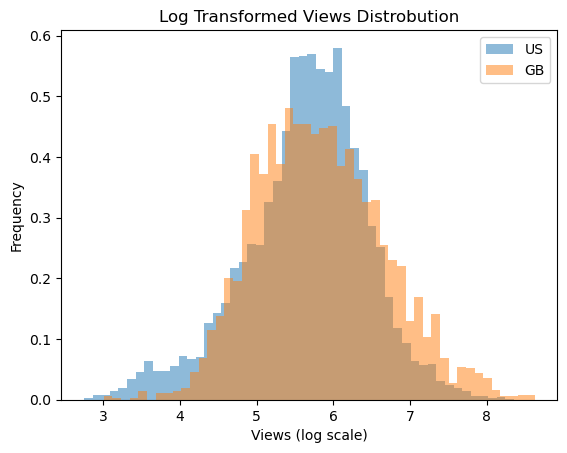

In [37]:
# histogram of views
plt.hist(np.log10(df_US_video['views']), bins=50, alpha=0.5, density=True, label='US') # log10 will continue to be used for our heavily skewed dataset
plt.hist(np.log10(df_GB_video['views']), bins=50, alpha=0.5, density=True, label='GB') # overlaying both plots at 50% transparency
plt.legend()
plt.xlabel('Views (log scale)')
plt.ylabel('Frequency')
plt.title('Log Transformed Views Distrobution')
plt.show()

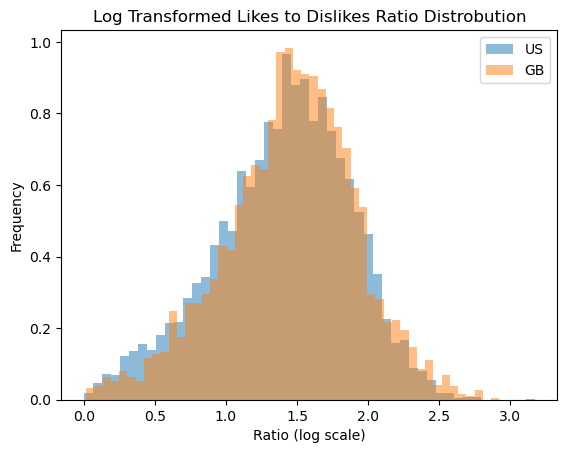

In [38]:
# Great Britain has an even tighter spread than the US but still shares the same mode of 1 million. 
# This suggests while viral videos are similar in viewership in both countries, in Great Britain those viewerships are much more dramatic
# histogram of ratio
plt.hist(np.log10(df_US_video['likes_to_dislikes'] + 1), bins=50, alpha=0.5, density=True, label='US') # encountered division by zero error, adding +1 to values
plt.hist(np.log10(df_GB_video['likes_to_dislikes'] + 1), bins=50, alpha=0.5, density=True, label='GB')
plt.legend()
plt.xlabel('Ratio (log scale)')
plt.ylabel('Frequency')
plt.title('Log Transformed Likes to Dislikes Ratio Distrobution')
plt.show()

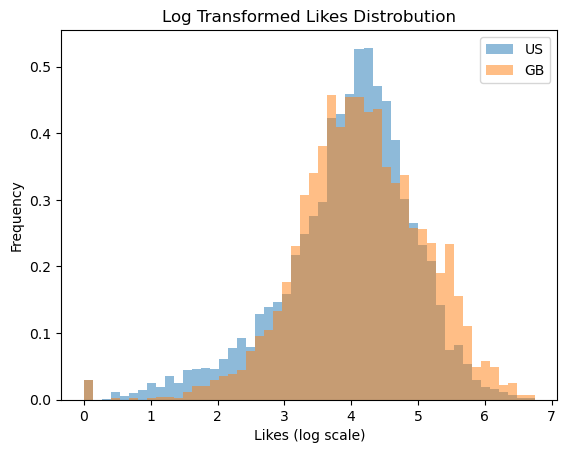

video_id             6351
views                6351
likes                6351
dislikes             6351
comment_count        6351
publish_time         6351
likes_to_dislikes    6258
dtype: int64
video_id             3272
views                3272
likes                3272
dislikes             3272
comment_count        3272
publish_time         3272
likes_to_dislikes    3249
dtype: int64


In [41]:
# normal log dsitrobution in like to dislike ratio for both countries
# 10^1.5 is about 31.5 likes per dislike
# a steep drop off at 100 likes per dislike and 10 likes per dislike, very polarizing videos are actually rare
# histogram of likes
plt.hist(np.log10(df_US_video['likes'] + 1), bins=50, alpha=0.5, density=True, label='US') # encountered division by zero error, adding +1 to values
plt.hist(np.log10(df_GB_video['likes'] + 1), bins=50, alpha=0.5, density=True, label='GB')
plt.legend()
plt.xlabel('Likes (log scale)')
plt.ylabel('Frequency')
plt.title('Log Transformed Likes Distrobution')
plt.show()

print(df_US_video.count()) # validating the size of each dataset
print(df_GB_video.count())

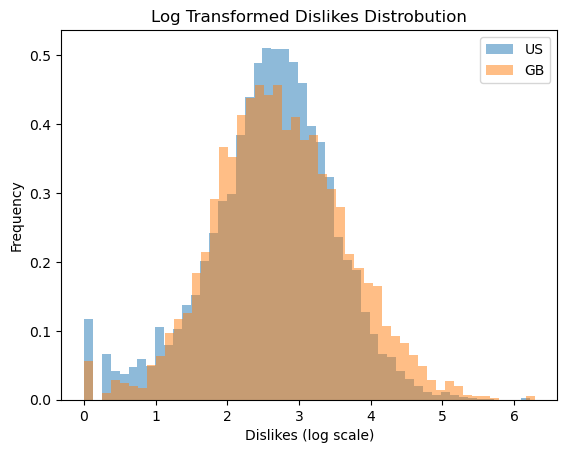

In [43]:
# histogram spread is fairly normal and both countries look the same
# Because density is set True, we avoid the issue of the US dataset being larger
# histogram of dislikes
plt.hist(np.log10(df_US_video['dislikes'] + 1), bins=50, alpha=0.5, density=True, label='US') # encountered division by zero error, adding +1 to values
plt.hist(np.log10(df_GB_video['dislikes'] + 1), bins=50, alpha=0.5, density=True, label='GB')
plt.legend()
plt.xlabel('Dislikes (log scale)')
plt.ylabel('Frequency')
plt.title('Log Transformed Dislikes Distrobution')
plt.show()

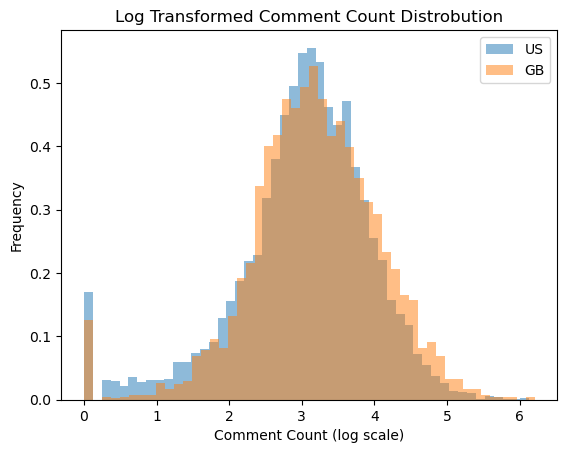

In [44]:
plt.hist(np.log10(df_US_video['comment_count'] + 1), bins=50, alpha=0.5, density=True, label='US') # encountered division by zero error, adding +1 to values
plt.hist(np.log10(df_GB_video['comment_count'] + 1), bins=50, alpha=0.5, density=True, label='GB')
plt.legend()
plt.xlabel('Comment Count (log scale)')
plt.ylabel('Frequency')
plt.title('Log Transformed Comment Count Distrobution')
plt.show()

In [50]:
# histograms all look fairly normal in log scale and are similar between countries
# answering the question, "whats the average ratio for all videos?"
all_df_video = pd.concat([df_US_video.assign(country='US'),
                          df_GB_video.assign(country='GB')])
print(all_df_video.head())

      video_id    views  likes  dislikes  comment_count  \
0  -0CMnp02rNY   800359   9773       332            423   
1  -0NYY8cqdiQ   563746   4429        54             94   
2  -1Hm41N0dUs  2058516  41248       580           1490   
3  -1yT-K3c6YI   231341   7734       212            846   
4  -2RVw2_QyxQ    71089    460        27             23   

               publish_time  likes_to_dislikes country  
0 2018-06-04 13:00:00+00:00          29.436747      US  
1 2018-01-29 14:00:39+00:00          82.018519      US  
2 2018-04-27 07:30:02+00:00          71.117241      US  
3 2017-11-28 18:30:43+00:00          36.481132      US  
4 2017-11-12 02:39:01+00:00          17.037037      US  


In [48]:
# creating a crosstable of variables
crosstable_us = df_US_video[[
    'views',
    'likes',
    'dislikes',
    'comment_count',
    'likes_to_dislikes',]].apply(np.log1p).corr()
print(crosstable_us)

                      views     likes  dislikes  comment_count  \
views              1.000000  0.876649  0.869976       0.790716   
likes              0.876649  1.000000  0.842847       0.857670   
dislikes           0.869976  0.842847  1.000000       0.823876   
comment_count      0.790716  0.857670  0.823876       1.000000   
likes_to_dislikes  0.137341  0.409152 -0.179558       0.173194   

                   likes_to_dislikes  
views                       0.137341  
likes                       0.409152  
dislikes                   -0.179558  
comment_count               0.173194  
likes_to_dislikes           1.000000  
